<a href="https://colab.research.google.com/github/mariyacode/elevate_labs_task1/blob/main/mall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [6]:
import zipfile

with zipfile.ZipFile('archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall()

import os
print(os.listdir())

['.config', 'archive (2).zip', 'Mall_Customers.csv', 'archive (2) (1).zip', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [10]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [11]:
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [13]:
print(df["Genre"].unique())

['Male' 'Female']


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Genre"] = le.fit_transform(df["Genre"])

print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1      1   19                  15                      39
1           2      1   21                  15                      81
2           3      0   20                  16                       6
3           4      0   23                  16                      77
4           5      0   31                  17                      40


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"]] = scaler.fit_transform(
    df[["Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"]]
)

print(df.head())

   CustomerID  Genre       Age  Annual Income (k$)  Spending Score (1-100)
0           1      1 -1.424569           -1.738999               -0.434801
1           2      1 -1.281035           -1.738999                1.195704
2           3      0 -1.352802           -1.700830               -1.715913
3           4      0 -1.137502           -1.700830                1.040418
4           5      0 -0.563369           -1.662660               -0.395980


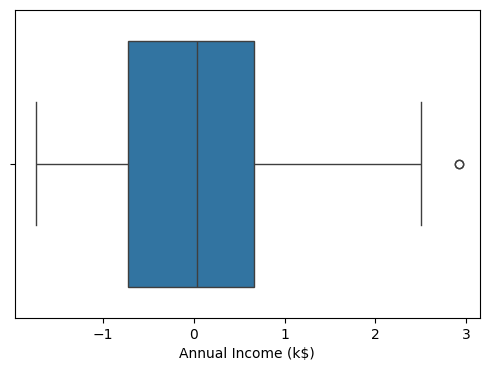

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Annual Income (k$)"])
plt.show()

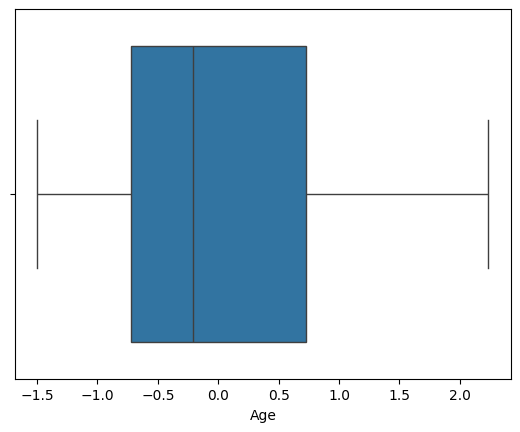

In [17]:
sns.boxplot(x=df["Age"])
plt.show()

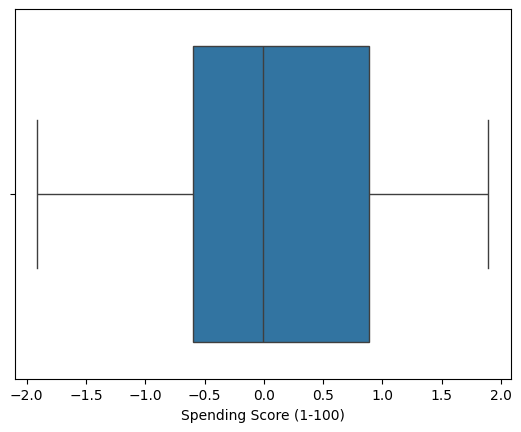

In [18]:
sns.boxplot(x=df["Spending Score (1-100)"])
plt.show()

In [19]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Age"] >= lower) &
        (df["Age"] <= upper)]

In [20]:
df.to_csv("cleaned_mall_customers.csv", index=False)